In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep='\t', names=[ "class", "message"])

df.head()

,class,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [123]:
df.shape

(5572, 2)

In [124]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   class    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


In [125]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
class      0
message    0
dtype: int64


In [126]:
print("\nClass Distribution:")
print(df["class"].value_counts())


Class Distribution:
class
ham     4825
spam     747
Name: count, dtype: int64


In [127]:
print("\nClass Percentage:")
print(df["class"].value_counts(normalize=True) * 100)


Class Percentage:
class
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


Thus Unbalanced in nature, which we will not change as we conduct our experiments on the said unbalanced data


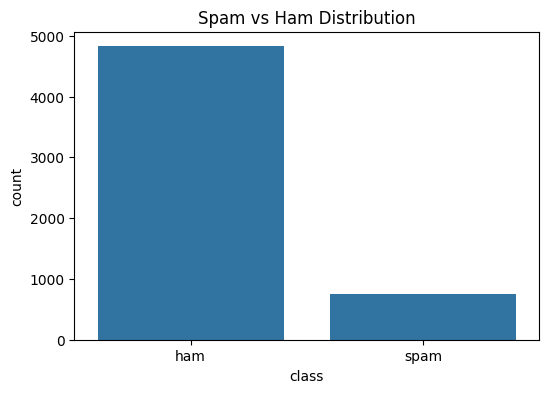

In [128]:
plt.figure(figsize=(6,4))
sns.countplot(x="class", data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

In [129]:
df["message_length"] = df["message"].apply(len)

df.head()

,class,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [130]:
print("\nMessage Length Statistics:")
print(df["message_length"].describe())


Message Length Statistics:
count    5572.000000
mean       80.489950
std        59.942907
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: message_length, dtype: float64


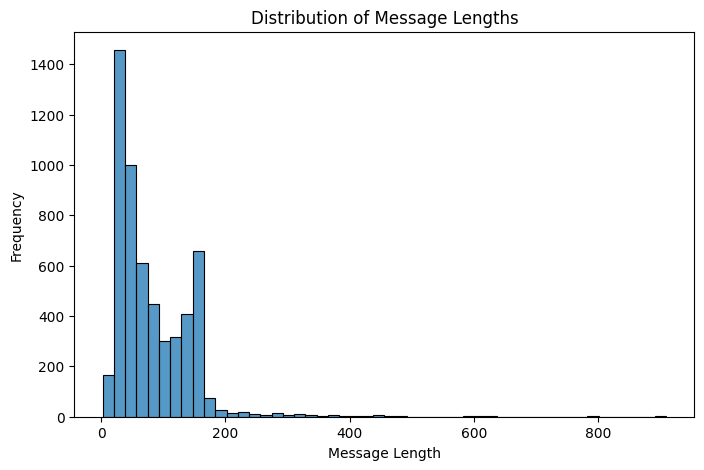

In [131]:
plt.figure(figsize=(8,5))
sns.histplot(df["message_length"], bins=50)
plt.title("Distribution of Message Lengths")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

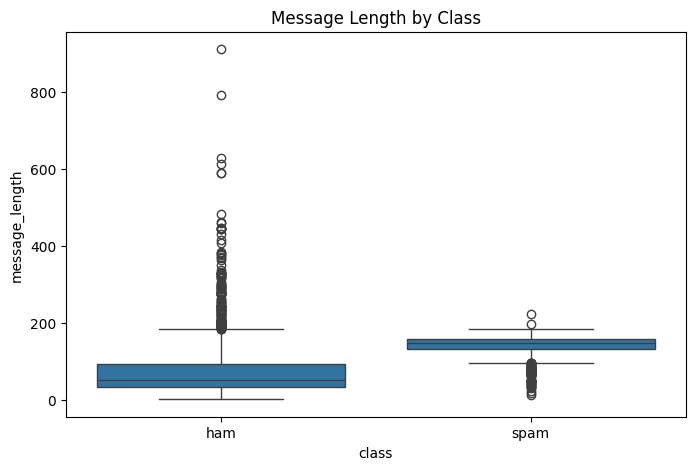

In [132]:
plt.figure(figsize=(8,5))
sns.boxplot(x="class", y="message_length", data=df)
plt.title("Message Length by Class")
plt.show()

Spam messages tend to be longer than ham messages.


In [133]:
from collections import Counter
import re
from wordcloud import WordCloud

all_words = " ".join(df["message"]).lower()
words = re.findall(r'\b\w+\b', all_words)

word_counts = Counter(words)
word_counts.most_common(10)


[('i', 3021),
 ('to', 2253),
 ('you', 2245),
 ('a', 1450),
 ('the', 1339),
 ('u', 1207),
 ('and', 980),
 ('in', 903),
 ('is', 897),
 ('me', 807)]

In [134]:
spam_words = " ".join(df[df["class"]=="spam"]["message"]).lower()
spam_words = re.findall(r'\b\w+\b', spam_words)
spam_counts = Counter(spam_words)
spam_counts.most_common(10)

[('to', 691),
 ('a', 380),
 ('call', 355),
 ('you', 297),
 ('your', 264),
 ('free', 224),
 ('2', 207),
 ('the', 206),
 ('for', 204),
 ('now', 199)]

In [135]:
ham_words = " ".join(df[df["class"]=="ham"]["message"]).lower()
ham_words = re.findall(r'\b\w+\b', ham_words)
ham_counts = Counter(ham_words)
ham_counts.most_common(10)

[('i', 2960),
 ('you', 1948),
 ('to', 1562),
 ('the', 1133),
 ('a', 1070),
 ('u', 1033),
 ('and', 858),
 ('in', 823),
 ('me', 777),
 ('my', 754)]

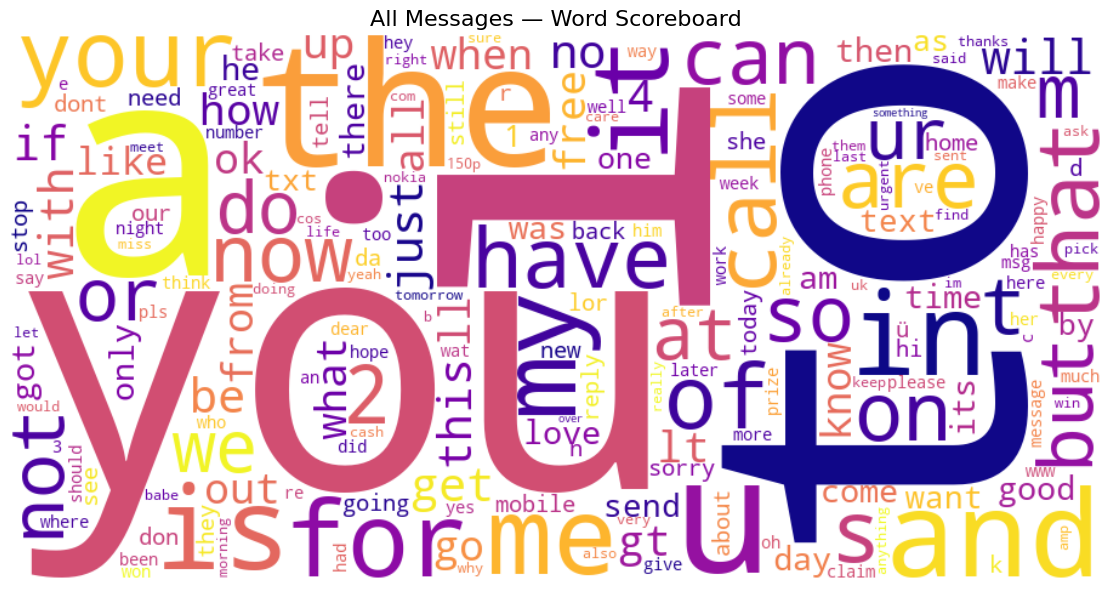

In [ ]:
from wordcloud import WordCloud

wc_all = WordCloud(width=900, height=450, background_color='white', colormap='plasma') \
         .generate_from_frequencies(word_counts)

plt.figure(figsize=(12, 6))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title("All Messages — Word Scoreboard", fontsize=16)
plt.tight_layout()
plt.show()

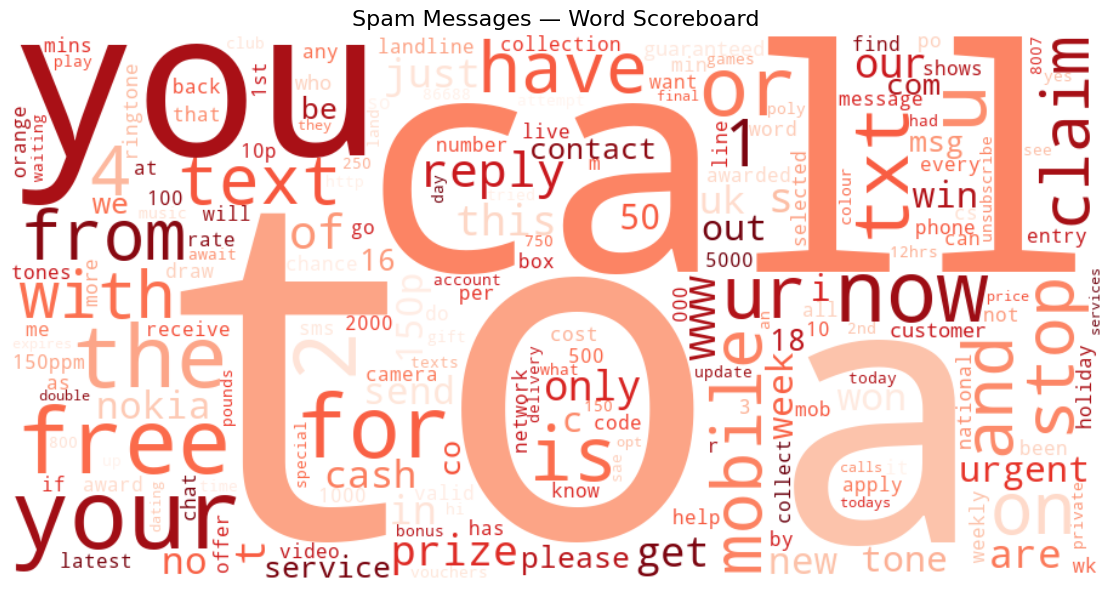

In [145]:
wc_spam = WordCloud(width=900, height=450, background_color='white', colormap='Reds') \
          .generate_from_frequencies(spam_counts)

plt.figure(figsize=(12, 6))
plt.imshow(wc_spam, interpolation='bilinear')
plt.axis('off')
plt.title("Spam Messages — Word Scoreboard", fontsize=16)
plt.tight_layout()
plt.show()

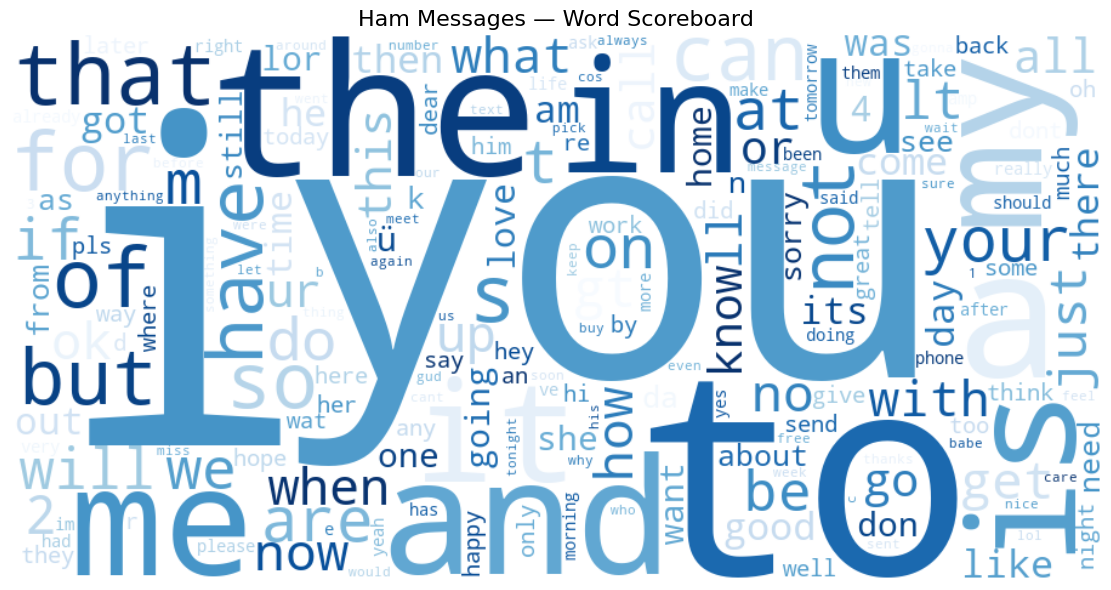

In [146]:
wc_ham = WordCloud(width=900, height=450, background_color='white', colormap='Blues') \
         .generate_from_frequencies(ham_counts)

plt.figure(figsize=(12, 6))
plt.imshow(wc_ham, interpolation='bilinear')
plt.axis('off')
plt.title("Ham Messages — Word Scoreboard", fontsize=16)
plt.tight_layout()
plt.show()

In [147]:
print("Average Ham Length:",
      df[df["class"]=="ham"]["message_length"].mean())

print("Average Spam Length:",
      df[df["class"]=="spam"]["message_length"].mean())

Average Ham Length: 71.48248704663213
Average Spam Length: 138.6706827309237
